In [1]:
%matplotlib inline
# %matplotlib notebook
from sklearn.model_selection import train_test_split
import numpy as np
import qutip as qt
from entVAE import vae_utils 
import matplotlib.pyplot as plt
import tensorflow as tf


I0000 00:00:1779101094.931524   40622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779101094.963078   40622 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779101096.127761   40622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

In [3]:
n_angle = 101
n_samples = 1000
scan_arr = np.linspace(0, np.pi, n_angle)
alpha_arr = np.zeros(101000)
cnt = 0
for theta in scan_arr:
        for _ in (range(n_samples)):
            alpha_arr[cnt] = theta
            cnt += 1

# Noiseless Dataset

Load Dataset

In [4]:
rho_arr_noiseless = np.load('../data/unitary_4x4_101_1000_noiseless.npy', mmap_mode="r")
X_train_noiseless, X_test_noiseless, y_train_noiseless, y_test_noiseless = train_test_split(rho_arr_noiseless, alpha_arr, random_state=42)
concurrence_noiseless_arr = np.array([qt.concurrence(qt.Qobj(dm.reshape(4,4),dims=[[2,2],[2,2]])) for dm in X_test_noiseless])

Define Hyperparameters and load trained VAE:

In [5]:
batch_size = 64
beta = 0.0
learning_rate = 0.0001
lat_dim = 1

encoder, decoder = vae_utils.vae_mlp_4x4(lat_dim, "relu", "tanh")
encoder.load_weights("../data/encoder_noiseless.h5")
decoder.load_weights("../data/decoder_noiseless.h5")

vae_noiseless = vae_utils.VAE(encoder, decoder, beta)
vae_noiseless.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))
# vae_noiseless.fit(X_test_noiseless, epochs=1, batch_size=64, verbose=1) 

z_mean_noiseless, z_log_var_noiseless, z_noiseless = vae_noiseless.encoder.predict(X_test_noiseless)

790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step


Investigate Latent Space

In [6]:
colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]
markers = ["o", "s", "^", "D", "v", "p"]

MS = 5 
LW = 1.2 
MW = 0.5

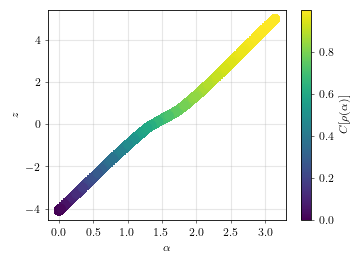

In [7]:
def plot_scatter(m_0, m_1, labels, title_x, title_y, title_cbar, alpha):
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    
    im = ax.scatter(m_0, m_1, c=labels, alpha=alpha,zorder=2)
    ax.set_xlabel(title_x)
    ax.set_ylabel(title_y)
    ax.grid(True, which="major", linestyle="-", alpha=0.3)
    ax.grid(True, which="minor", linestyle=":", alpha=0.15)
    cbar = fig.colorbar(im)
    cbar.set_label(title_cbar)
    fig.tight_layout(pad=0.3)
    plt.show()

plot_scatter(y_test_noiseless,z_mean_noiseless[:,0],concurrence_noiseless_arr,"$\\alpha$","$z$","$C[\\rho(\\alpha)]$",1)

# Concurrence

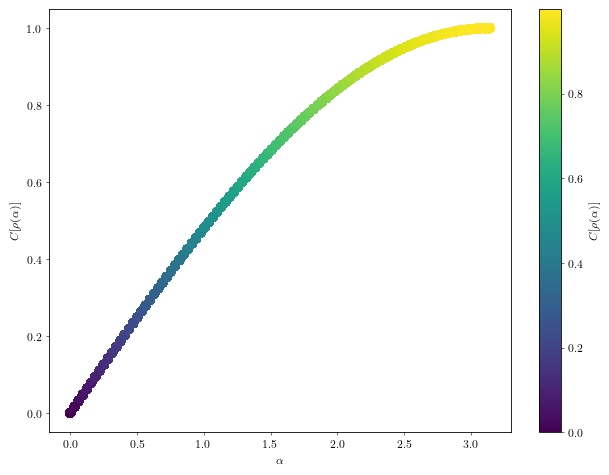

In [8]:
X_train, X_test, y_train, y_test = train_test_split(rho_arr_noiseless, alpha_arr, random_state=42)
conc_plot = np.array([qt.concurrence(qt.Qobj(dm.reshape(4,4),dims=[[2,2],[2,2]])) for dm in X_test])
# conc_plot = np.unique(conc_plot)
fig,ax = plt.subplots()
im = ax.scatter(y_test,conc_plot,c=conc_plot)
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("$C[\\rho(\\alpha)]$")
cbar = fig.colorbar(im)
cbar.set_label("$C[\\rho(\\alpha)]$")
plt.tight_layout()
# plt.savefig("/home/felix/Downloads/fig10_concurrence.pdf")